# UD DDM Records — Dataset Demo

This notebook demonstrates the **UD DDM Records** dataset: per-dependency records extracted from Universal Dependencies treebanks. Each record encodes treebank ID, dependency relation, POS tags, sentence length, morphological case features, and dependency distance.

**What this script does:**
1. Loads pre-extracted dependency records from multiple UD treebanks
2. Analyzes dependency distance distributions across languages
3. Compares case-rich vs. analytic languages

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
from collections import defaultdict
from statistics import mean

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load Data

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-3bc3de-sentence-length-standardization-reveals-/main/dataset_iter1_ud_ddm_records/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} treebanks, {sum(len(d['examples']) for d in data['datasets'])} total records")

Loaded 5 treebanks, 15 total records


## Parse Records

Each record's `input` field encodes: `treebank|deprel|depPOS|headPOS|sentLen|depCase|headCase`, and `output` is the dependency distance.

In [5]:
# Parse all records into a flat list of dicts
rows = []
for ds in data["datasets"]:
    for ex in ds["examples"]:
        parts = ex["input"].split("|")
        rows.append({
            "treebank": parts[0],
            "deprel": parts[1],
            "dep_pos": parts[2],
            "head_pos": parts[3],
            "sent_len": int(parts[4]),
            "dep_case": parts[5],
            "head_case": parts[6],
            "distance": int(ex["output"]),
        })

df = pd.DataFrame(rows)
print(f"Parsed {len(df)} records")
df.head()

Parsed 15 records


,treebank,deprel,dep_pos,head_pos,sent_len,dep_case,head_case,distance
0,ar_padt,nsubj,X,VERB,13,_,_,1
1,ar_padt,obj,NOUN,VERB,13,Acc,_,1
2,ar_padt,nmod,NOUN,NOUN,13,Gen,Acc,1
3,cs_cac,amod,ADJ,NOUN,25,Nom,Nom,1
4,cs_cac,nsubj,NOUN,VERB,25,Nom,_,2


## Treebank Metadata

Summary statistics and case inventories per treebank.

In [6]:
# Display treebank metadata
tb_meta = data["metadata"]["treebank_metadata"]
meta_df = pd.DataFrame(tb_meta)
print(meta_df[["treebank_id", "language_code", "num_sentences", "mean_sentence_length", "num_case_values"]].to_string(index=False))

treebank_id language_code  num_sentences  mean_sentence_length  num_case_values
    ar_padt            ar           7664                 36.85                3
     en_ewt            en          16622                 15.33                3
     de_gsd            de          15589                 18.78                4
     cs_cac            cs          24709                 20.01                7
  es_ancora            es          17662                 31.71                6


## Visualization: Dependency Distance by Treebank & Case Richness

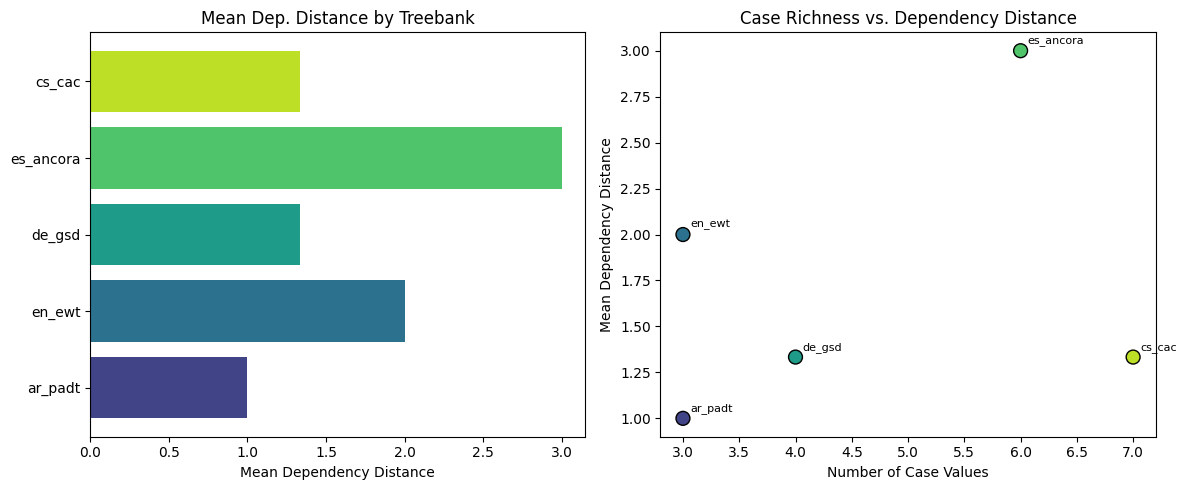


Summary:
 treebank  num_cases     mean  count
  ar_padt          3 1.000000      3
   en_ewt          3 2.000000      3
   de_gsd          4 1.333333      3
es_ancora          6 3.000000      3
   cs_cac          7 1.333333      3


In [7]:
# Map treebank -> num_case_values from metadata
case_map = {m["treebank_id"]: m["num_case_values"] for m in tb_meta}

# Mean dependency distance per treebank
tb_stats = df.groupby("treebank")["distance"].agg(["mean", "std", "count"]).reset_index()
tb_stats["num_cases"] = tb_stats["treebank"].map(case_map)
tb_stats = tb_stats.sort_values("num_cases")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: mean dependency distance per treebank
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(tb_stats)))
ax.barh(tb_stats["treebank"], tb_stats["mean"], color=colors)
ax.set_xlabel("Mean Dependency Distance")
ax.set_title("Mean Dep. Distance by Treebank")

# Scatter: case richness vs mean distance
ax = axes[1]
ax.scatter(tb_stats["num_cases"], tb_stats["mean"], s=100, c=colors, edgecolors="black", zorder=5)
for _, row in tb_stats.iterrows():
    ax.annotate(row["treebank"], (row["num_cases"], row["mean"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("Number of Case Values")
ax.set_ylabel("Mean Dependency Distance")
ax.set_title("Case Richness vs. Dependency Distance")

plt.tight_layout()
plt.show()

# Summary table
print("\nSummary:")
print(tb_stats[["treebank", "num_cases", "mean", "count"]].to_string(index=False))